<a href="https://colab.research.google.com/github/Sarkis55/Air_Quality_Predictor/blob/main/BSAN6070_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
# Combine the 2021, 2022, 2023, 2024, and 2025 PM2.5 California Datasets from https://www.epa.gov/outdoor-air-quality-data/download-daily-data

import pandas as pd
import glob

# Find all CSV files that match the naming pattern
files = glob.glob("ad_viz_plotval_data*.csv")

print("Files found:", files)

# Combine them
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Shape:", df.shape)
df.head()

Files found: ['ad_viz_plotval_data_2022.csv', 'ad_viz_plotval_data_2023.csv', 'ad_viz_plotval_data_2024.csv', 'ad_viz_plotval_data_2021.csv', 'ad_viz_plotval_data_2025.csv']
Shape: (295383, 22)


,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,60010007,3,12.7,ug/m3 LC,58,Livermore,1,100.0,...,170.0,Met One BAM-1020 Mass Monitor w/VSCC,41860.0,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.687526,-121.784217
1,01/02/2022,AQS,60010007,3,13.9,ug/m3 LC,60,Livermore,1,100.0,...,170.0,Met One BAM-1020 Mass Monitor w/VSCC,41860.0,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.687526,-121.784217
2,01/03/2022,AQS,60010007,3,7.1,ug/m3 LC,39,Livermore,1,100.0,...,170.0,Met One BAM-1020 Mass Monitor w/VSCC,41860.0,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.687526,-121.784217
3,01/04/2022,AQS,60010007,3,3.7,ug/m3 LC,21,Livermore,1,100.0,...,170.0,Met One BAM-1020 Mass Monitor w/VSCC,41860.0,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.687526,-121.784217
4,01/05/2022,AQS,60010007,3,4.2,ug/m3 LC,23,Livermore,1,100.0,...,170.0,Met One BAM-1020 Mass Monitor w/VSCC,41860.0,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.687526,-121.784217


## Data Preprocessing

In [92]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')

In [93]:
#only keep columns that are necessary

df = df[[
    'Date',
    'Daily AQI Value',
    'Daily Mean PM2.5 Concentration',
    'County',
    'Site Latitude',
    'Site Longitude'
]]

In [94]:
#rename some columns
df = df.rename(columns={
    'Daily AQI Value': 'AQI',
    'Daily Mean PM2.5 Concentration': 'PM25'
})

In [95]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Drop rows where date failed OR AQI missing
df = df.dropna(subset=['Date', 'AQI', 'PM25'])

# Remove duplicates
df = df.drop_duplicates()

In [96]:
df.describe()

,Date,AQI,PM25,Site Latitude,Site Longitude
count,293447,293447.000000,293447.000000,293447.000000,293447.000000
mean,2023-06-24 09:13:15.663953152,39.055789,8.417070,36.278086,-119.653720
min,2021-01-01 00:00:00,0.000000,-6.700000,32.552824,-124.203470
25%,2022-03-25 00:00:00,23.000000,4.100000,34.100020,-121.493110
50%,2023-06-18 00:00:00,37.000000,6.700000,36.489470,-119.691218
75%,2024-09-20 00:00:00,54.000000,10.500000,37.962069,-117.938450
max,2025-12-31 00:00:00,1435.000000,794.900000,41.756130,-115.483070
std,NaN,23.004232,9.030783,2.322166,2.034045


In [97]:
# Remove invalid values
df = df[(df['PM25'] >= 0) & (df['AQI'] >= 0)]

#Remove extreme outliers
df = df[df['PM25'] < df['PM25'].quantile(0.99)]

In [98]:
df.head()
df['Date'].head()

,Date
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05


In [99]:
# Create Target Variable
# 1 = Unhealthy, 0 = Safe

df['AQI_Category'] = df['AQI'].apply(lambda x: 1 if x > 75 else 0)

df['AQI_Category'].value_counts()

,count
AQI_Category,
0,281286
1,7780


In [100]:
df.head()

,Date,AQI,PM25,County,Site Latitude,Site Longitude,AQI_Category
0,2022-01-01,58,12.7,Alameda,37.687526,-121.784217,0
1,2022-01-02,60,13.9,Alameda,37.687526,-121.784217,0
2,2022-01-03,39,7.1,Alameda,37.687526,-121.784217,0
3,2022-01-04,21,3.7,Alameda,37.687526,-121.784217,0
4,2022-01-05,23,4.2,Alameda,37.687526,-121.784217,0


In [101]:
# Feature Engineering

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Season (VERY important for pollution patterns)
df['Season'] = df['Month'] % 12 // 3 + 1

In [102]:
# Add location feature
df['County_Code'] = df['County'].astype('category').cat.codes

# Scale PM2.5
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['PM25'] = scaler.fit_transform(df[['PM25']])

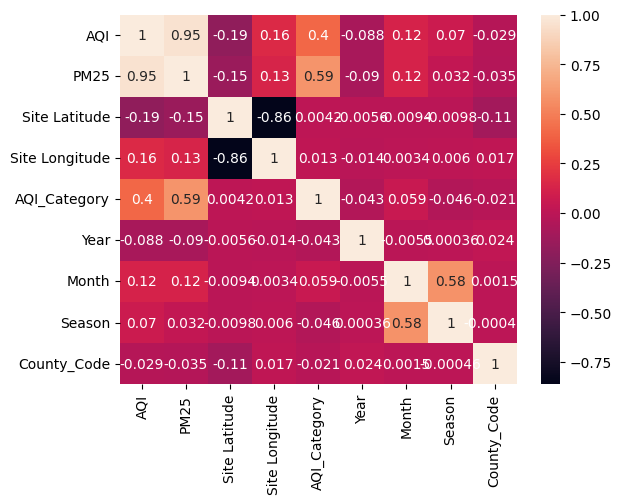

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [104]:
# Define Features + Target

features = ['AQI', 'Month', 'Season', 'County_Code']
X = df[features]
y = df['AQI_Category']

In [105]:
from sklearn.model_selection import train_test_split

#Splitting training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic Regression

In [106]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [107]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Creating classification report to evaluate model performance
print('\nClassification Report:')
print(classification_report(y_test, y_pred))




Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56282
           1       1.00      1.00      1.00      1532

    accuracy                           1.00     57814
   macro avg       1.00      1.00      1.00     57814
weighted avg       1.00      1.00      1.00     57814



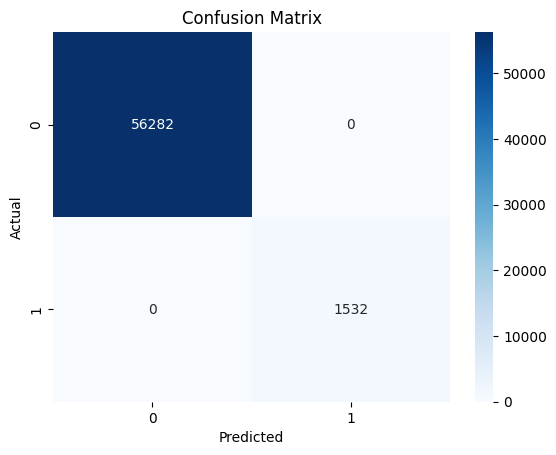

In [78]:
#Creating confusion matrix
cm = confusion_matrix(y_test, y_pred)

#Visualizing Confusion matrix using seaborne
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()